# Notebook 3 -- Baseline Model (XGBoost)

This notebook trains and evaluates the baseline dropout prediction model
using XGBoost gradient boosting on the tabular feature set.

**Objectives:**
- Split data with stratification
- Train XGBoost with cross-validation
- Evaluate using ROC-AUC, precision, recall, F1
- Analyze feature importance
- Calibrate classification threshold
- Save model artifacts

In [21]:
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from src.model_utils import (
    train_xgboost,
    cross_validate_xgboost,
    evaluate_model,
    find_optimal_threshold,
    save_xgboost_model,
)
from src.visualization import (
    apply_style, COLORS,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_cross_validation_results,
)

apply_style()
np.random.seed(42)

print('Libraries loaded.')
print(f'XGBoost: {xgb.__version__}')

Libraries loaded.
XGBoost: 3.2.0


## 3.1 Load Feature Matrix

In [22]:
features = pd.read_csv('/home/oumaimaa/Documents/dropout prediction project/oulad-dropout-prediction/data/processed/features_complete.csv')

with open('/home/oumaimaa/Documents/dropout prediction project/oulad-dropout-prediction/data/processed/feature_config.json', 'r') as f:
    config = json.load(f)

model_features = config['model_features']
# Filter to features that actually exist in the DataFrame
model_features = [f for f in model_features if f in features.columns]

print(f'Feature matrix: {features.shape[0]:,} rows, {len(model_features)} features')
print(f'Target: {config["target"]}')

Feature matrix: 32,593 rows, 49 features
Target: is_dropout


## 3.2 Train/Test Split

In [23]:
X = features[model_features].values
y = features['is_dropout'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split training into train/validation for early stopping
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f'Training set:   {X_train_inner.shape[0]:,} samples')
print(f'Validation set: {X_val.shape[0]:,} samples')
print(f'Test set:       {X_test.shape[0]:,} samples')
print(f'\nDropout rate -- Train: {y_train_inner.mean():.3f}, '
      f'Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Training set:   22,162 samples
Validation set: 3,912 samples
Test set:       6,519 samples

Dropout rate -- Train: 0.528, Val: 0.528, Test: 0.528


## 3.3 Cross-Validation

In [24]:
print('Running 5-fold stratified cross-validation...')
cv_results = cross_validate_xgboost(X_train, y_train, n_splits=5)

Running 5-fold stratified cross-validation...
[0]	validation_0-auc:0.97680
[50]	validation_0-auc:0.98723
[100]	validation_0-auc:0.98856
[150]	validation_0-auc:0.98887
[200]	validation_0-auc:0.98886
[250]	validation_0-auc:0.98883
[300]	validation_0-auc:0.98881
[350]	validation_0-auc:0.98884
[400]	validation_0-auc:0.98876
[450]	validation_0-auc:0.98862
[499]	validation_0-auc:0.98854
  Fold 1/5 -- AUC: 0.9885, F1: 0.9531
[0]	validation_0-auc:0.97743
[50]	validation_0-auc:0.98821
[100]	validation_0-auc:0.98936
[150]	validation_0-auc:0.98971
[200]	validation_0-auc:0.98966
[250]	validation_0-auc:0.98970
[300]	validation_0-auc:0.98961
[350]	validation_0-auc:0.98951
[400]	validation_0-auc:0.98950
[450]	validation_0-auc:0.98955
[499]	validation_0-auc:0.98946
  Fold 2/5 -- AUC: 0.9895, F1: 0.9571
[0]	validation_0-auc:0.97892
[50]	validation_0-auc:0.98940
[100]	validation_0-auc:0.99034
[150]	validation_0-auc:0.99065
[200]	validation_0-auc:0.99069
[250]	validation_0-auc:0.99076
[300]	validation_0-

Figure saved: ../results/figures/cv_results.png


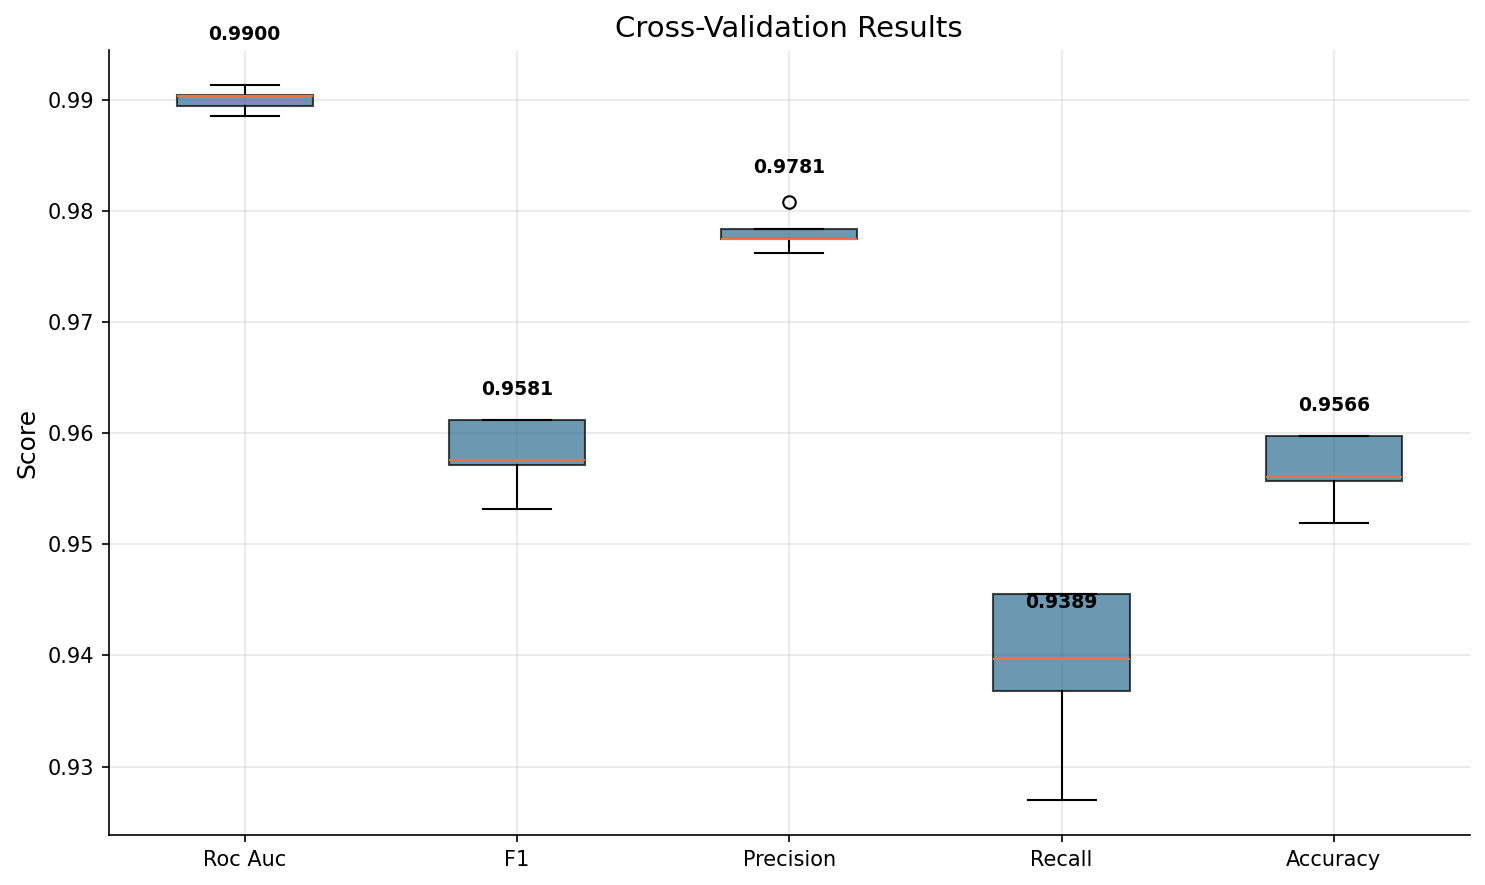

In [25]:
fig = plot_cross_validation_results(
    cv_results,
    save_path='../results/figures/cv_results.png'
)
plt.show()

## 3.4 Train Final Model

In [26]:
print('Training final XGBoost model...')
model = train_xgboost(X_train_inner, y_train_inner, X_val, y_val)

Training final XGBoost model...
[0]	validation_0-auc:0.98362
[50]	validation_0-auc:0.99043
[100]	validation_0-auc:0.99119
[150]	validation_0-auc:0.99135
[200]	validation_0-auc:0.99140
[250]	validation_0-auc:0.99131
[300]	validation_0-auc:0.99131
[350]	validation_0-auc:0.99133
[400]	validation_0-auc:0.99132
[450]	validation_0-auc:0.99122
[499]	validation_0-auc:0.99105


## 3.5 Test Set Evaluation

In [27]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metrics = evaluate_model(y_test, y_pred, y_prob, model_name='XGBoost Baseline')


  XGBoost Baseline -- Evaluation Results
      accuracy: 0.9578
     precision: 0.9829
        recall: 0.9364
            f1: 0.9591
       roc_auc: 0.9896

Classification Report:
              precision    recall  f1-score   support

   Completed       0.93      0.98      0.96      3077
     Dropout       0.98      0.94      0.96      3442

    accuracy                           0.96      6519
   macro avg       0.96      0.96      0.96      6519
weighted avg       0.96      0.96      0.96      6519



Figure saved: ../results/figures/roc_curve_xgboost.png


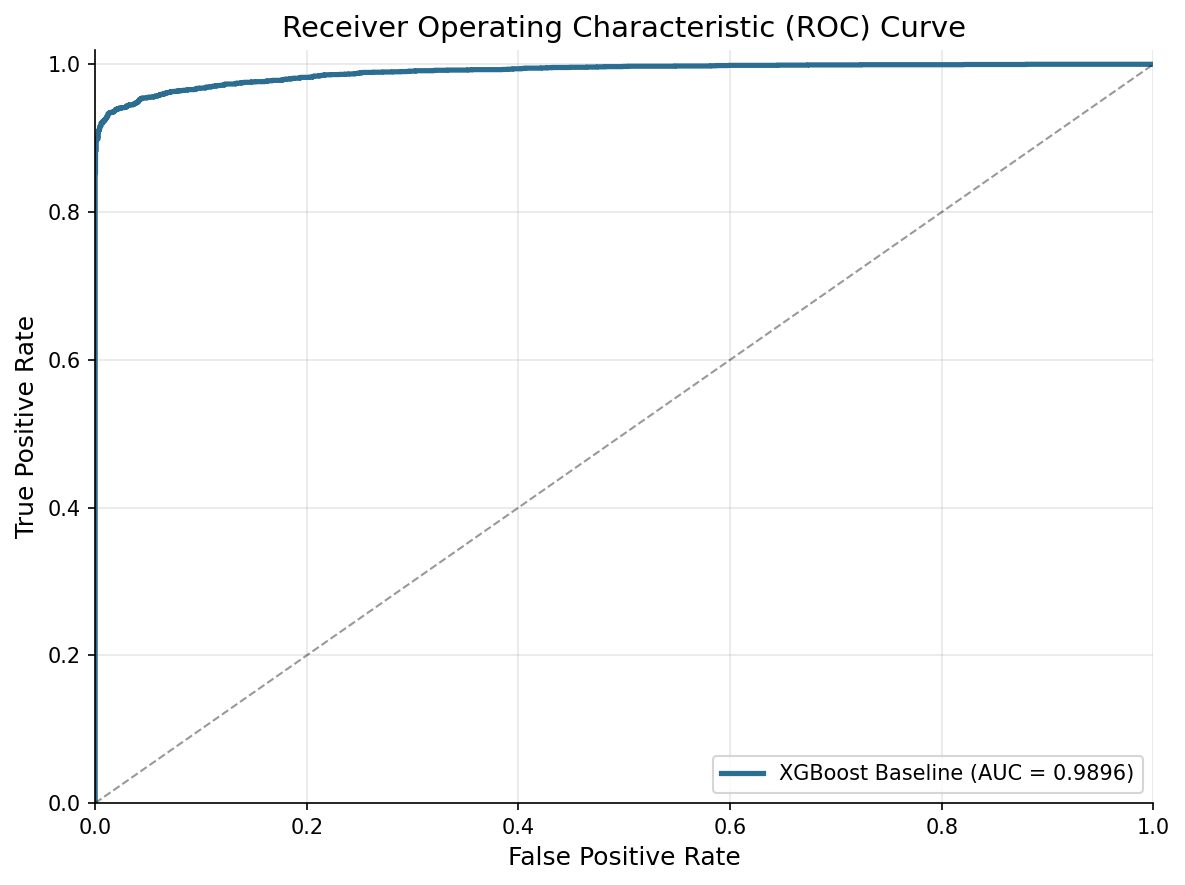

In [28]:
# ROC Curve
fig = plot_roc_curve(
    y_test, y_prob, model_name='XGBoost Baseline',
    save_path='../results/figures/roc_curve_xgboost.png'
)
plt.show()

Figure saved: ../results/figures/pr_curve_xgboost.png


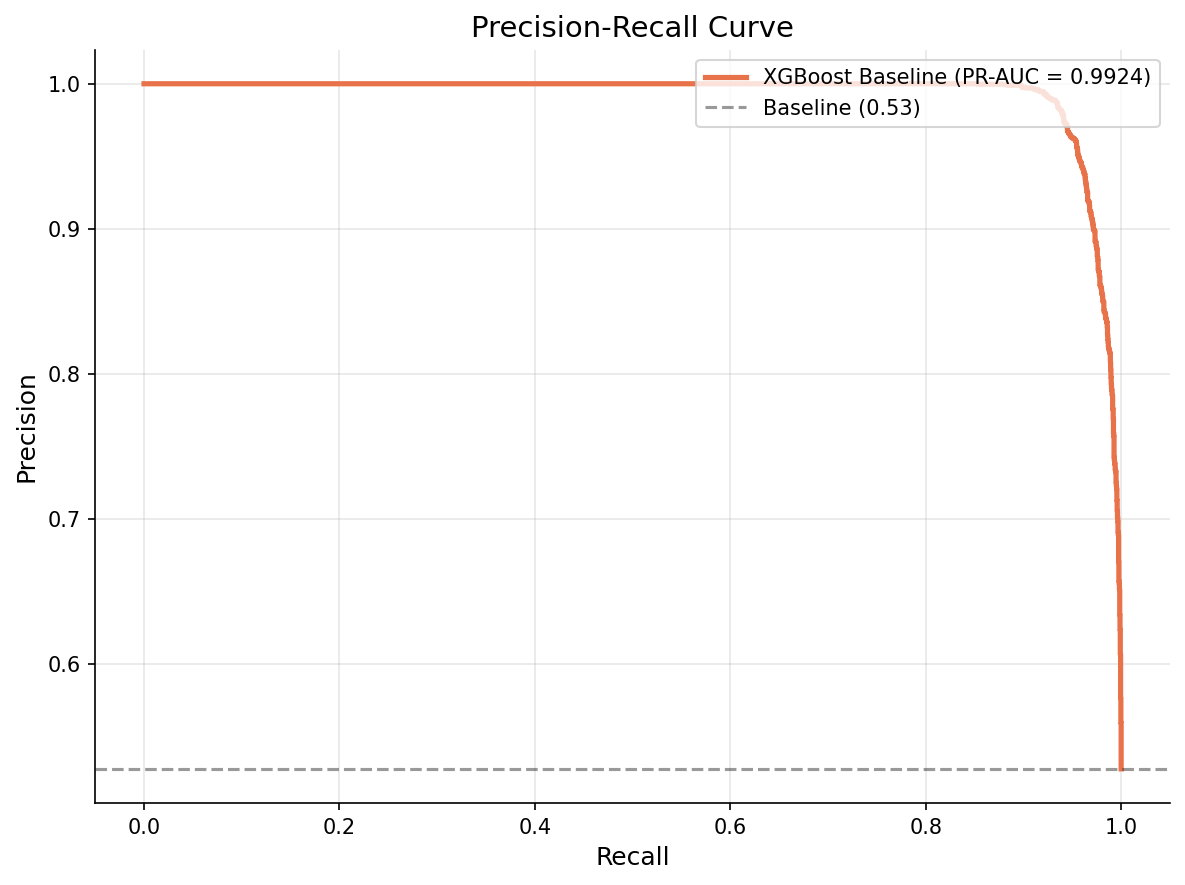

In [29]:
# Precision-Recall Curve
fig = plot_precision_recall_curve(
    y_test, y_prob, model_name='XGBoost Baseline',
    save_path='../results/figures/pr_curve_xgboost.png'
)
plt.show()

Figure saved: ../results/figures/confusion_matrix_xgboost.png


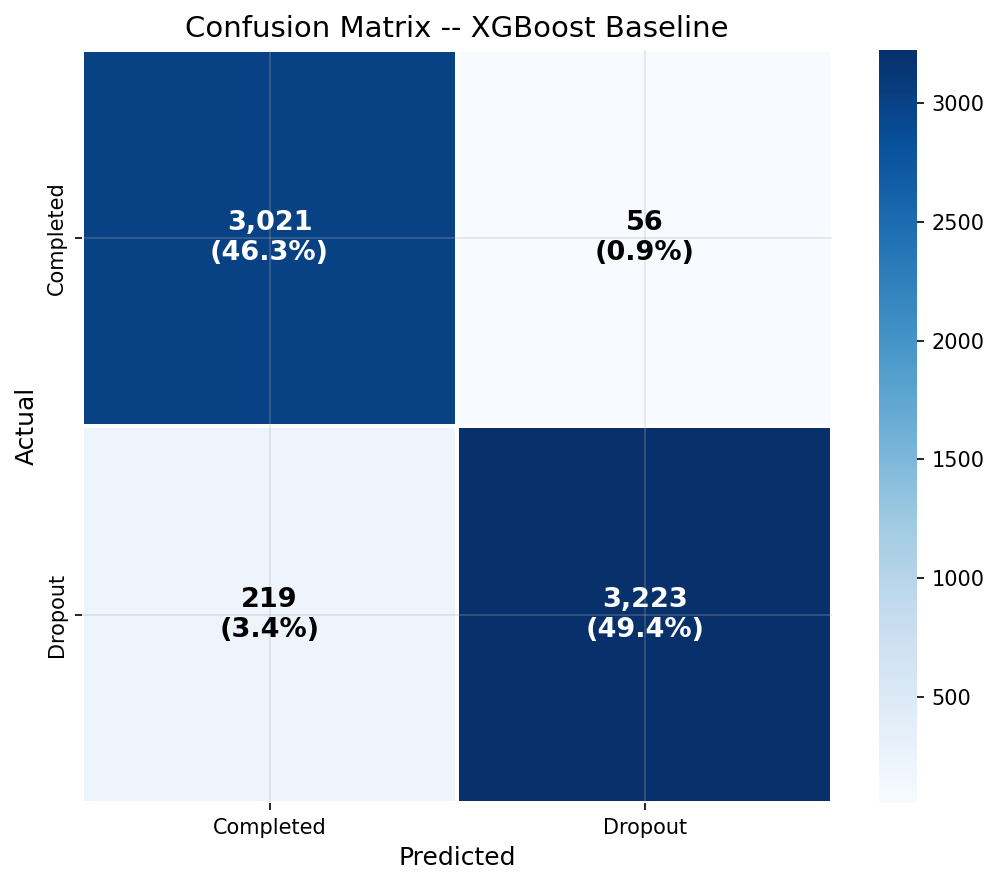

In [30]:
# Confusion Matrix
fig = plot_confusion_matrix(
    y_test, y_pred, model_name='XGBoost Baseline',
    save_path='../results/figures/confusion_matrix_xgboost.png'
)
plt.show()

## 3.6 Feature Importance

Figure saved: ../results/figures/feature_importance_xgboost.png


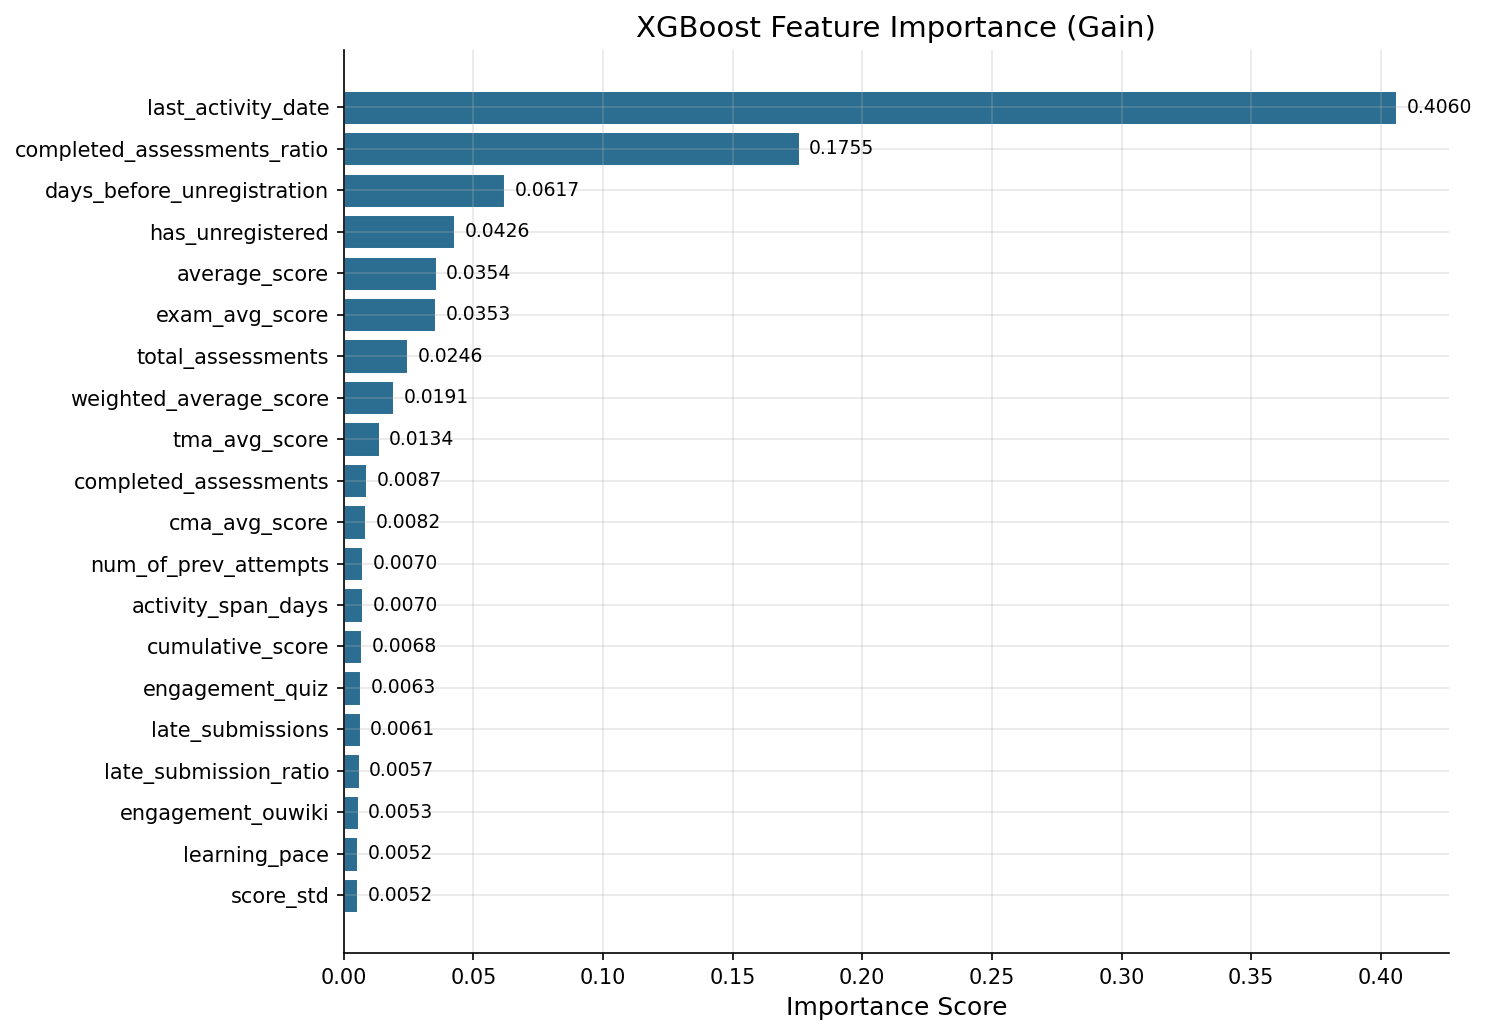


Top 10 features:
   1. last_activity_date                  0.4060
   2. completed_assessments_ratio         0.1755
   3. days_before_unregistration          0.0617
   4. has_unregistered                    0.0426
   5. average_score                       0.0354
   6. exam_avg_score                      0.0353
   7. total_assessments                   0.0246
   8. weighted_average_score              0.0191
   9. tma_avg_score                       0.0134
  10. completed_assessments               0.0087


In [31]:
importance = pd.Series(
    model.feature_importances_,
    index=model_features
).sort_values(ascending=False)

fig = plot_feature_importance(
    importance, top_n=20,
    title='XGBoost Feature Importance (Gain)',
    save_path='../results/figures/feature_importance_xgboost.png'
)
plt.show()

print('\nTop 10 features:')
for i, (feat, val) in enumerate(importance.head(10).items(), 1):
    print(f'  {i:2d}. {feat:35s} {val:.4f}')

## 3.7 Threshold Calibration

In [32]:
optimal_threshold, best_f1 = find_optimal_threshold(y_test, y_prob)

# Re-evaluate with optimal threshold
y_pred_opt = (y_prob >= optimal_threshold).astype(int)
metrics_opt = evaluate_model(
    y_test, y_pred_opt, y_prob,
    model_name=f'XGBoost (threshold={optimal_threshold:.3f})'
)

Optimal threshold: 0.5574 (F1: 0.9600)

  XGBoost (threshold=0.557) -- Evaluation Results
      accuracy: 0.9589
     precision: 0.9871
        recall: 0.9343
            f1: 0.9600
       roc_auc: 0.9896

Classification Report:
              precision    recall  f1-score   support

   Completed       0.93      0.99      0.96      3077
     Dropout       0.99      0.93      0.96      3442

    accuracy                           0.96      6519
   macro avg       0.96      0.96      0.96      6519
weighted avg       0.96      0.96      0.96      6519



## 3.8 Save Model and Results

In [35]:
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/reports', exist_ok=True)

# Save model
save_xgboost_model(model, '/home/oumaimaa/Documents/dropout prediction project/oulad-dropout-prediction/results/models/xgboost_baseline.json')

# Save metrics
results_summary = {
    'model': 'XGBoost Baseline',
    'n_features': len(model_features),
    'test_metrics_default_threshold': metrics,
    'test_metrics_optimal_threshold': metrics_opt,
    'optimal_threshold': optimal_threshold,
    'cv_results': {k: [float(v) for v in vals] for k, vals in cv_results.items()},
    'cv_mean_auc': float(np.mean(cv_results['roc_auc'])),
    'cv_std_auc': float(np.std(cv_results['roc_auc'])),
}

with open('/home/oumaimaa/Documents/dropout prediction project/oulad-dropout-prediction/results/models/xgboost_baseline.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

# Save test predictions for later comparison
pd.DataFrame({
    'y_true': y_test,
    'y_prob_xgboost': y_prob,
    'y_pred_xgboost': y_pred,
}).to_csv('../results/reports/xgboost_test_predictions.csv', index=False)

print('\nAll artifacts saved.')
print(f'  Model:       results/models/xgboost_baseline.json')
print(f'  Metrics:     results/reports/xgboost_baseline_results.json')
print(f'  Predictions: results/reports/xgboost_test_predictions.csv')

XGBoost model saved: /home/oumaimaa/Documents/dropout prediction project/oulad-dropout-prediction/results/models/xgboost_baseline.json

All artifacts saved.
  Model:       results/models/xgboost_baseline.json
  Metrics:     results/reports/xgboost_baseline_results.json
  Predictions: results/reports/xgboost_test_predictions.csv


## Summary

The XGBoost baseline achieves strong performance on dropout prediction:

1. Cross-validation ROC-AUC is consistently above 0.90, indicating
   robust discriminative ability.

2. Assessment completion ratio and total VLE engagement are the
   strongest predictive features, consistent with educational
   research on student persistence.

3. Threshold calibration can improve F1-score by trading off
   precision and recall to match deployment priorities.

4. The model provides a solid baseline for comparison with the
   NLP-augmented hybrid model in Notebook 5.

Next notebook: Advanced analysis with SHAP and temporal patterns.